<a href="https://colab.research.google.com/github/Muhammad-Musharraf/Stroke-prediction-ANN-Projects/blob/main/Strokes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stroke Prediction System

## 🧠 Stroke — Short Description

**Stroke is a medical emergency that occurs when blood flow to part of the brain is blocked or when a blood vessel in the brain bursts, causing brain cells to die due to lack of oxygen.** It can lead to weakness, speech problems, paralysis, memory loss, or even death if not treated quickly.

---

## ✅ Types of Stroke

* **Ischemic Stroke** → caused by blood clot blockage
* **Hemorrhagic Stroke** → caused by bleeding in the brain
* **TIA (Mini Stroke)** → temporary blockage warning sign  ([CDC][1])

---

## ⚠️ Common Symptoms

Use **FAST**:

* **F** → Face drooping
* **A** → Arm weakness
* **S** → Speech difficulty
* **T** → Time to call emergency help  ([Mayo Clinic][2])

---

## 📌 project definition

**Stroke is a sudden interruption of blood supply to the brain that damages brain cells and can cause disability or death.**



# Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Download Dataset From KaggleHub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/stroke-prediction-dataset


In [ ]:
os.listdir(path)

['healthcare-dataset-stroke-data.csv']

# Read the Dataset

In [ ]:
df=pd.read_csv(path+'/healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# **Data Preprocessing & EDA**

In [ ]:
df.rename(columns={'heart_disease':"heart disease","ever_married":"Married","avg_glucose_level":"Avg_Glucose_Level","smoking_status":"Smoking Status","work_type":"Work Type"},inplace=True)

In [ ]:
df.head()

,id,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.drop('id',axis=1,inplace=True)

In [ ]:
df.head()

,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.shape

(5110, 11)

In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart disease,0
Married,0
Work Type,0
Residence_type,0
Avg_Glucose_Level,0
bmi,201
Smoking Status,0


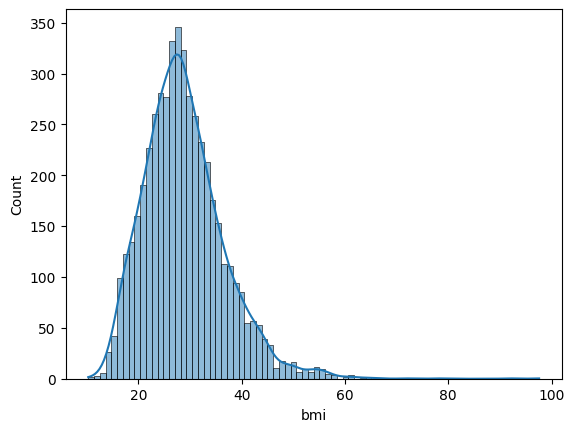

In [ ]:
sns.histplot(df['bmi'],kde=True)
plt.show()

In [ ]:
df['bmi'].skew()

np.float64(1.0553402052962912)

In [ ]:
df['bmi'].mean()

np.float64(28.893236911794666)

In [ ]:
df['bmi'].median()

28.1

In [ ]:
df.fillna(df['bmi'].median(),inplace=True)

In [ ]:
df['bmi'].isnull().sum()

np.int64(0)

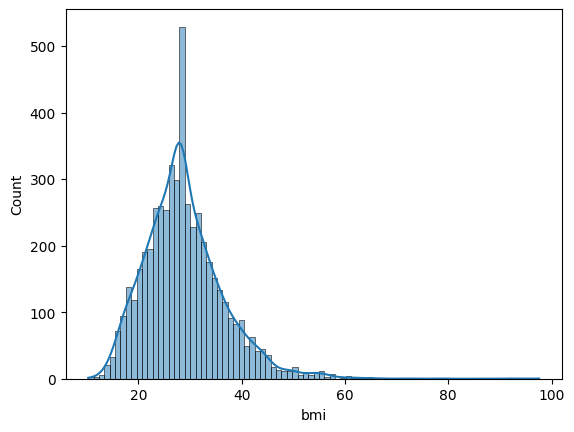

In [ ]:
sns.histplot(df['bmi'],kde=True)
plt.show()

In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart disease,0
Married,0
Work Type,0
Residence_type,0
Avg_Glucose_Level,0
bmi,0
Smoking Status,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.sample(5)

,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status,stroke
4590,Female,82.0,1,1,Yes,Self-employed,Urban,101.56,31.5,never smoked,0
1739,Female,16.0,0,0,No,Self-employed,Urban,88.85,27.1,Unknown,0
1183,Male,73.0,1,0,Yes,Self-employed,Rural,102.06,28.1,Unknown,0
4316,Male,30.0,0,0,No,Private,Urban,113.08,41.8,Unknown,0
2758,Female,60.0,0,0,Yes,Private,Rural,85.60,34.5,Unknown,0


In [ ]:
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart disease,int64
Married,object
Work Type,object
Residence_type,object
Avg_Glucose_Level,float64
bmi,float64
Smoking Status,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart disease      5110 non-null   int64  
 4   Married            5110 non-null   object 
 5   Work Type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   Avg_Glucose_Level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   Smoking Status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [ ]:
df.describe()

,age,hypertension,heart disease,Avg_Glucose_Level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.862035,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.699562,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
df['age']=df['age'].astype("int64")

In [ ]:
df["age"].head()

,age
0,67
1,61
2,80
3,49
4,79


# Check All Unique Values

In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
df['Married'].value_counts()

,count
Married,
Yes,3353
No,1757


In [ ]:
df['Smoking Status'].value_counts()

,count
Smoking Status,
never smoked,1892
Unknown,1544
formerly smoked,885
smokes,789


In [ ]:
df['gender'].value_counts()

,count
gender,
Female,2994
Male,2115
Other,1


In [ ]:
df['heart disease'].value_counts()

,count
heart disease,
0,4834
1,276


In [ ]:
df['hypertension'].value_counts()

,count
hypertension,
0,4612
1,498


In [ ]:
df['Work Type'].value_counts()

,count
Work Type,
Private,2925
Self-employed,819
children,687
Govt_job,657
Never_worked,22


In [ ]:
df['Residence_type'].value_counts()

,count
Residence_type,
Urban,2596
Rural,2514


In [ ]:
df['Avg_Glucose_Level'].unique()

array([228.69, 202.21, 105.92, ...,  82.99, 166.29,  85.28])

In [ ]:
df['age'].unique()

array([67, 61, 80, 49, 79, 81, 74, 69, 59, 78, 54, 50, 64, 75, 60, 57, 71,
       52, 82, 65, 58, 42, 48, 72, 63, 76, 39, 77, 73, 56, 45, 70, 66, 51,
       43, 68, 47, 53, 38, 55,  1, 46, 32, 14,  3,  8, 37, 40, 35, 20, 44,
       25, 27, 23, 17, 13,  4, 16, 22, 30, 29, 11, 21, 18, 33, 24, 34, 36,
        0, 41,  5, 26, 31,  7, 12, 62,  2,  9, 15, 28, 10, 19,  6])

# Data Visualization

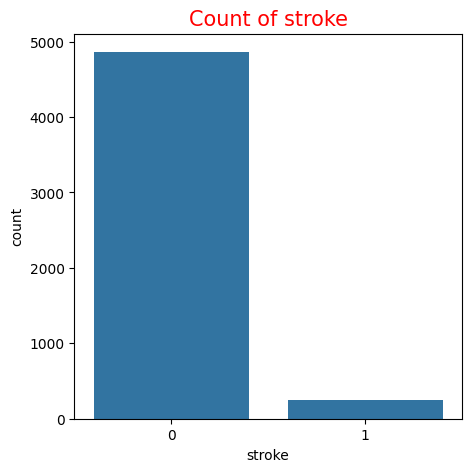

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x='stroke',data=df)
plt.title('Count of stroke',color='red',fontsize=15)
plt.show()

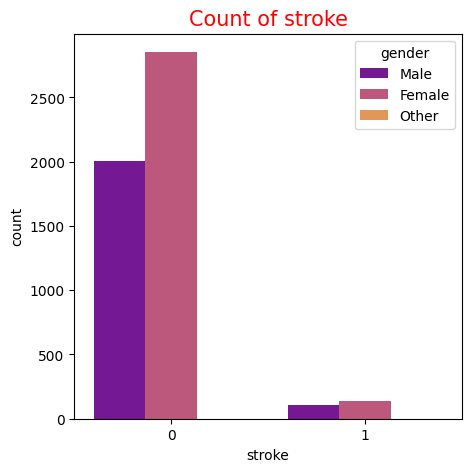

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x='stroke',data=df,hue='gender',palette='plasma')
plt.title('Count of stroke',color='red',fontsize=15)
plt.show()

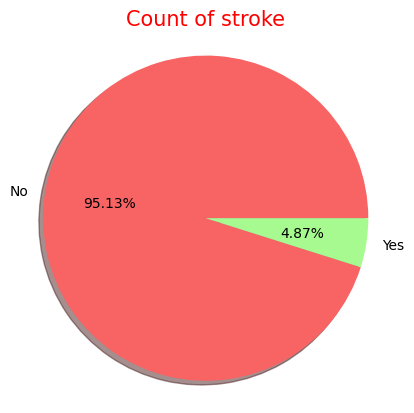

In [ ]:
plt.pie(df['stroke'].value_counts(),labels=['No','Yes'],autopct='%.2f%%',colors=["#F86363","#A6FA8F"],radius=1.1,shadow=True)
plt.title('Count of stroke',color='red',fontsize=15)
plt.show()

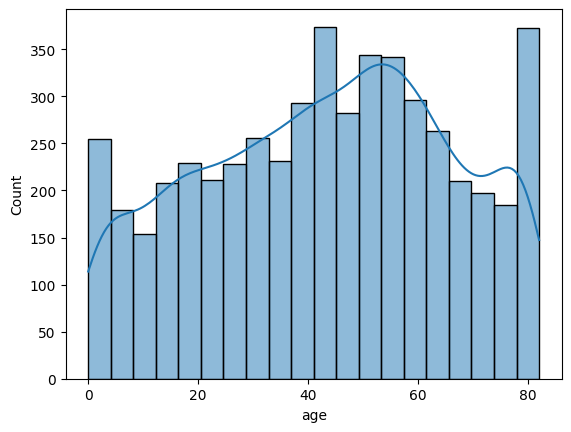

In [ ]:
sns.histplot(df['age'],kde=True)
plt.show()

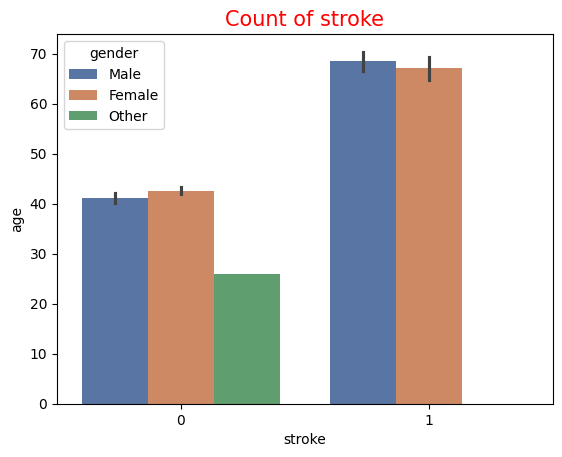

In [ ]:
sns.barplot(y='age',x='stroke',data=df,hue="gender",palette='deep')
plt.title('Count of stroke',color='red',fontsize=15)
plt.show()

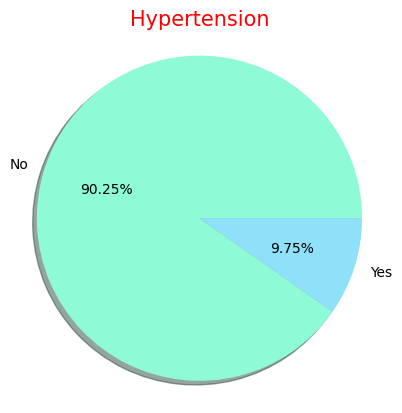

In [ ]:
plt.pie(df['hypertension'].value_counts(),labels=['No','Yes'],autopct='%.2f%%',colors=["#8FFAD6","#8FE1FA"],radius=1.1,shadow=True)
plt.title('Hypertension',color='red',fontsize=15)
plt.show()

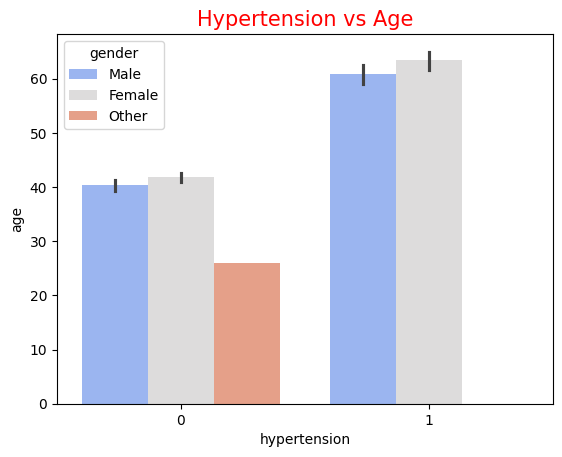

In [ ]:
sns.barplot(y='age',x='hypertension',data=df,hue="gender",palette='coolwarm')
plt.title('Hypertension vs Age',color='red',fontsize=15)
plt.show()

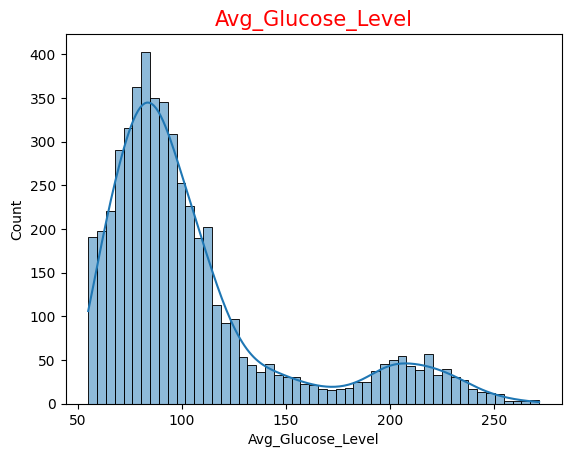

In [ ]:
sns.histplot(df['Avg_Glucose_Level'],kde=True)
plt.title('Avg_Glucose_Level',color='red',fontsize=15)
plt.show()

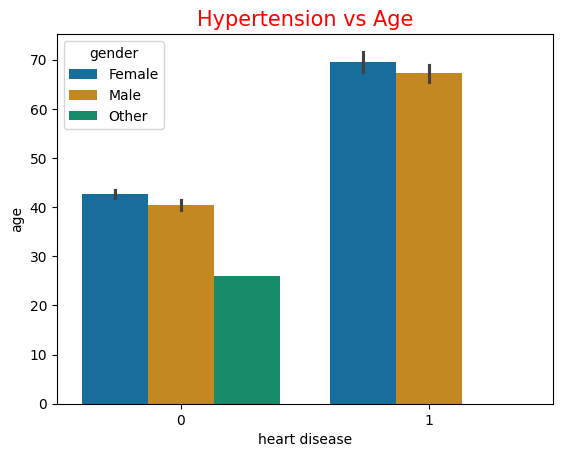

In [ ]:
sns.barplot(y='age',x='heart disease',data=df,hue="gender",palette='colorblind')
plt.title('Hypertension vs Age',color='red',fontsize=15)
plt.show()

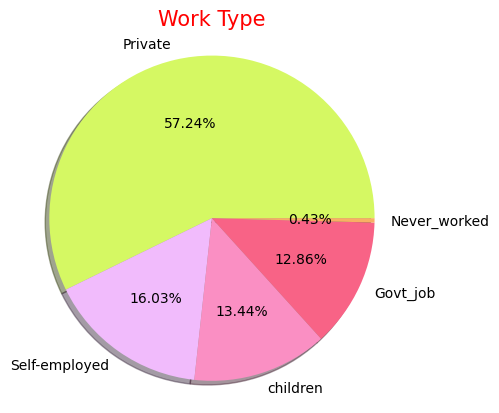

In [ ]:
plt.pie(df['Work Type'].value_counts(),labels=df["Work Type"].value_counts().index,autopct='%.2f%%',colors=["#D5F863","#F1BBFC","#FA8FC3","#F86386","#F8B063"],radius=1.1,shadow=True)
plt.title('Work Type',color='red',fontsize=15)
plt.show()

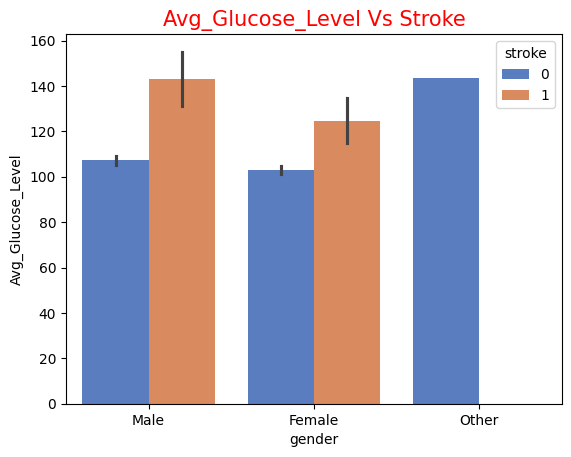

In [ ]:
sns.barplot(y='Avg_Glucose_Level',x='gender',data=df,hue="stroke",palette='muted')
plt.title('Avg_Glucose_Level Vs Stroke',color='red',fontsize=15)
plt.show()

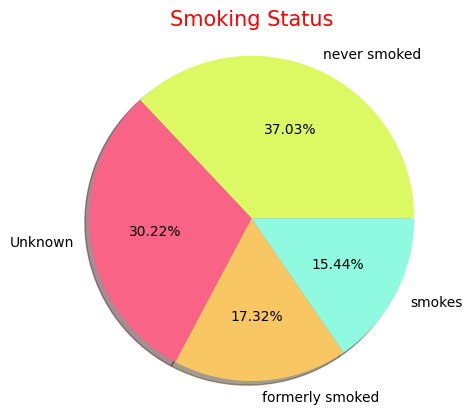

In [ ]:
plt.pie(df['Smoking Status'].value_counts(),labels=df["Smoking Status"].value_counts().index,autopct='%.2f%%',colors=["#DCF863","#F86386","#F8C663","#8FFADF"],radius=1.1,shadow=True)
plt.title('Smoking Status',color='red',fontsize=15)
plt.show()

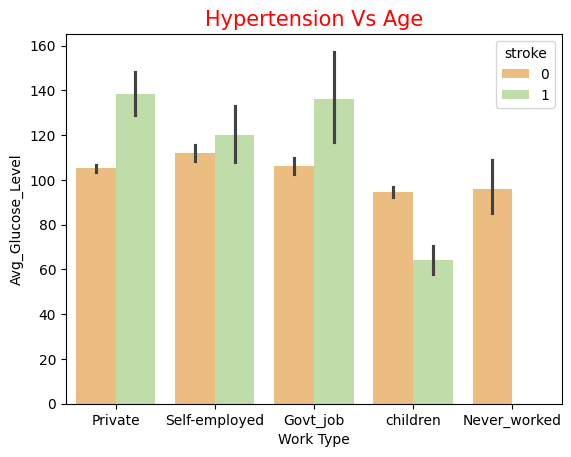

In [ ]:
sns.barplot(x='Work Type',y='Avg_Glucose_Level',data=df,hue="stroke",palette='Spectral')
plt.title('Hypertension Vs Age',color='red',fontsize=15)
plt.show()

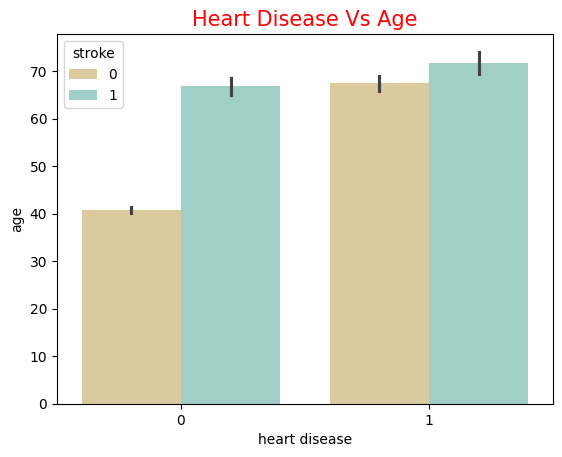

In [ ]:
sns.barplot(y='age',x='heart disease',data=df,hue="stroke",palette='BrBG')
plt.title('Heart Disease Vs Age',color='red',fontsize=15)
plt.show()

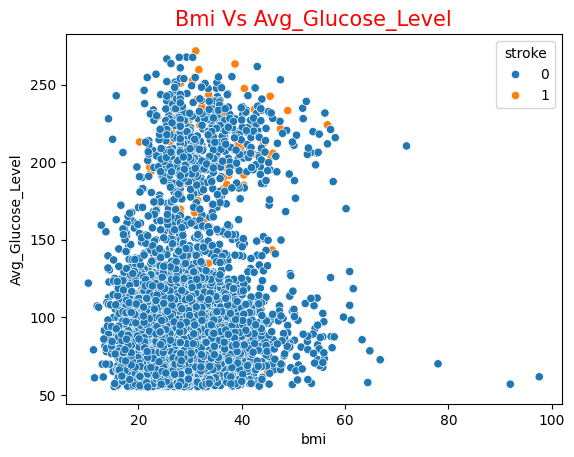

In [ ]:
sns.scatterplot(data=df,x="bmi",y="Avg_Glucose_Level",color='blue',marker="o",hue="stroke")
plt.title('Bmi Vs Avg_Glucose_Level',color='red',fontsize=15)
plt.show()

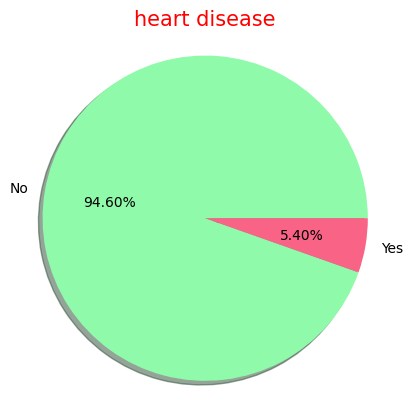

In [ ]:
plt.pie(df['heart disease'].value_counts(),labels=['No','Yes'],autopct='%.2f%%',colors=["#8FFAAA","#F86386"],radius=1.1,shadow=True)
plt.title('heart disease',color='red',fontsize=15)
plt.show()

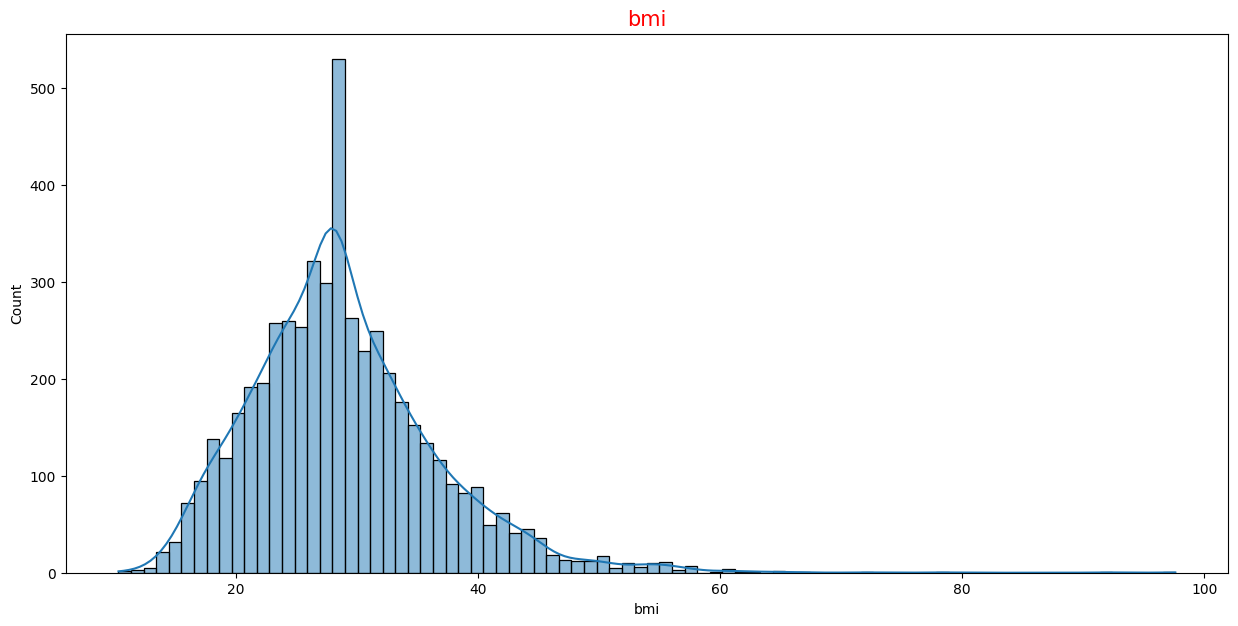

In [ ]:
plt.figure(figsize=(15,7))
sns.histplot(df['bmi'],kde=True)
plt.title('bmi',color='red',fontsize=15)
plt.show()

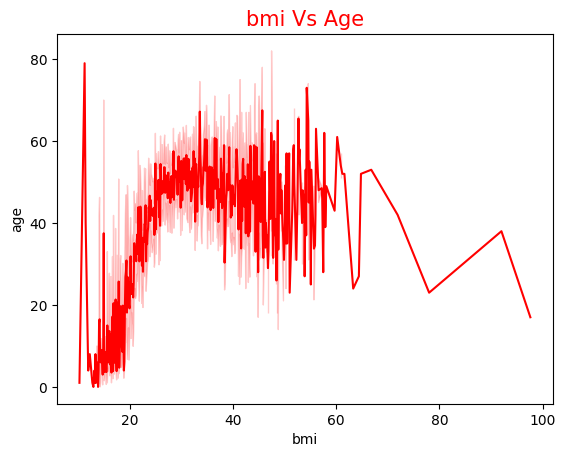

In [ ]:
sns.lineplot(data=df,x="bmi",y="age",color='red')
plt.title('bmi Vs Age',color='red',fontsize=15)
plt.show()

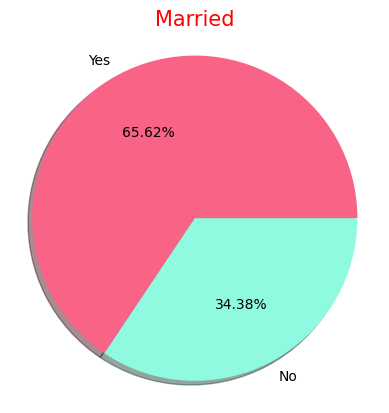

In [ ]:
plt.pie(df['Married'].value_counts(),labels=df["Married"].value_counts().index,autopct='%.2f%%',colors=["#F86386","#8FFADF"],radius=1.1,shadow=True)
plt.title('Married',color='red',fontsize=15)
plt.show()

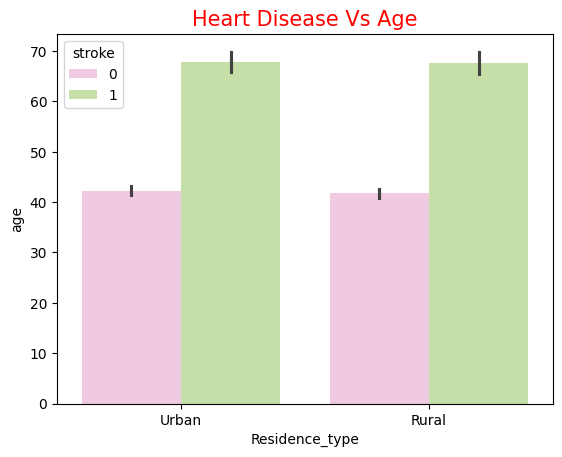

In [ ]:
sns.barplot(y='age',x='Residence_type',data=df,hue="stroke",palette='PiYG')
plt.title('Heart Disease Vs Age',color='red',fontsize=15)
plt.show()

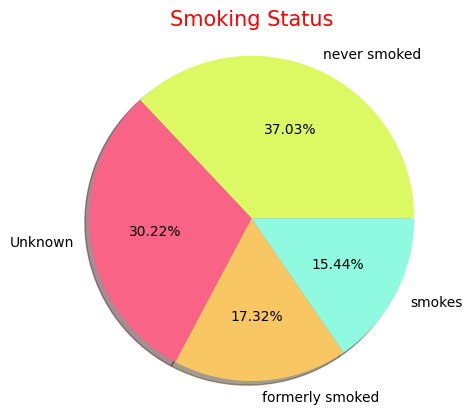

In [ ]:
plt.pie(df['Smoking Status'].value_counts(),labels=df["Smoking Status"].value_counts().index,autopct='%.2f%%',colors=["#DCF863","#F86386","#F8C663","#8FFADF"],radius=1.1,shadow=True)
plt.title('Smoking Status',color='red',fontsize=15)
plt.show()

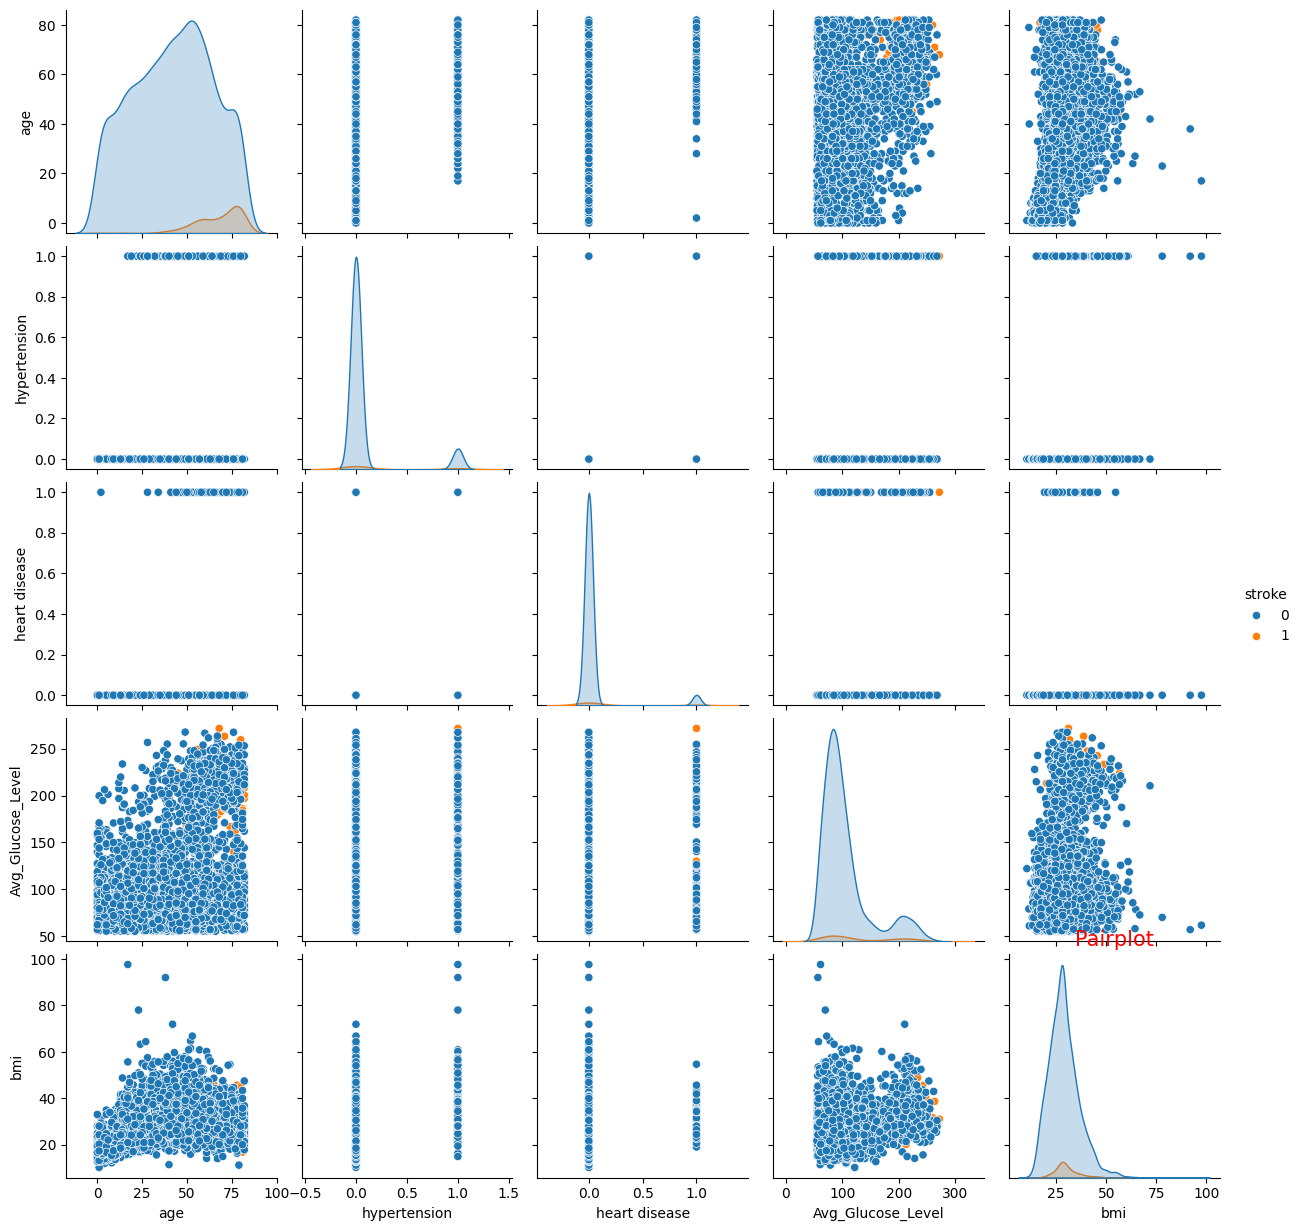

In [ ]:
sns.pairplot(df,hue="stroke")
plt.title('Pairplot',color='red',fontsize=15)
plt.show()

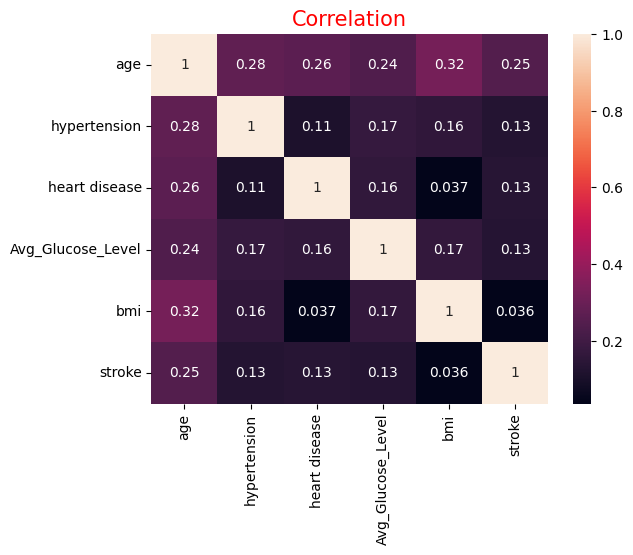

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title('Correlation',color='red',fontsize=15)
plt.show()

# Data Encoding And Scaling

In [ ]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline

# Split X and Y

In [ ]:
x=df.drop(columns=["stroke"],axis=1)
y=df["stroke"]

In [ ]:
ohe=OneHotEncoder(handle_unknown='ignore')
ohe.fit(x[["gender","Married","Work Type","Residence_type","Smoking Status"]])

OneHotEncoder(handle_unknown='ignore')

In [ ]:
ss=StandardScaler()
ss.fit(x[["age","Avg_Glucose_Level","bmi","heart disease","hypertension"]])

StandardScaler()

In [ ]:
df.head()

,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Train Test Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# from imblearn.over_sampling import SMOTE
# oversample = SMOTE()
# X_train_resh, y_train_resh = oversample.fit_resample(x_train, y_train)

In [ ]:
column_trans=make_column_transformer(
    (ohe,["gender","Married","Work Type","Residence_type","Smoking Status"]),
    (ss,["age","Avg_Glucose_Level","bmi","heart disease","hypertension"]),
    remainder="passthrough"
)

In [ ]:
column_trans

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Married', 'Work Type',
                                  'Residence_type', 'Smoking Status']),
                                ('standardscaler', StandardScaler(),
                                 ['age', 'Avg_Glucose_Level', 'bmi',
                                  'heart disease', 'hypertension'])])

In [ ]:
x_train_tranform=column_trans.fit_transform(x_train)
x_test_transform=column_trans.transform(x_test)

In [ ]:
x_train

,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status
802,Male,79,0,0,Yes,Self-employed,Rural,112.64,28.5,formerly smoked
3927,Female,62,0,0,Yes,Private,Urban,88.32,36.3,Unknown
2337,Female,21,0,0,No,Private,Rural,59.52,33.7,never smoked
3910,Male,31,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked
1886,Female,31,0,0,No,Private,Rural,59.63,19.9,never smoked
...,...,...,...,...,...,...,...,...,...,...
4426,Male,43,0,0,Yes,Govt_job,Rural,88.00,30.6,never smoked
466,Female,61,1,0,Yes,Private,Rural,170.05,60.2,smokes
3092,Female,1,0,0,No,children,Urban,97.28,17.8,Unknown
3772,Male,80,0,0,Yes,Self-employed,Rural,196.08,31.0,formerly smoked


In [ ]:
x.head()

,gender,age,hypertension,heart disease,Married,Work Type,Residence_type,Avg_Glucose_Level,bmi,Smoking Status
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked
2,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked
3,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked


In [ ]:
y.head()

,stroke
0,1
1,1
2,1
3,1
4,1


In [ ]:
x.shape

(5110, 10)

In [ ]:
y.shape

(5110,)

In [ ]:
# X_train_resh.shape

In [ ]:
pd.Series(y_train).value_counts()

,count
stroke,
0,3901
1,187


In [ ]:
# pd.Series(y_train_resh).value_counts()

# **Data Modeling With Artifical Neural Network (ANN) Architecture**

# Import Tensorflow Library

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [ ]:
# Dropout randomly turns off neurons during training.


model = tf.keras.Sequential([
    # Input Layers
    tf.keras.layers.InputLayer(input_shape=(x_train_tranform.shape[1],)),


    # dense Layers
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),



    # Output Layers
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


# Model Summary

In [ ]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.metrics import F1Score,Accuracy,Precision,Recall,AUC
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy','Precision','Recall']
)

# **Early Stoping:**
Early Stopping is a technique used in machine learning and deep learning (including TensorFlow) to stop training automatically when the model stops improving on validation data

In [ ]:

# early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


## 📊 **Model Performance Interpretation Theory**

### 🔴 1. Training accuracy >> Validation accuracy

This indicates **overfitting**.
The model performs very well on training data but poorly on unseen validation data, meaning it has memorized the training data instead of learning general patterns.

---

### 🟡 2. Training accuracy << Validation accuracy

This is uncommon and may indicate **underfitting or data mismatch**.
The model is not learning the training data properly, or validation data may be easier than training data.

---

### 🟢 3. Training accuracy ≈ Validation accuracy

This indicates a **well-balanced model (good fit)**.
The model has learned general patterns and performs consistently on both training and validation data, showing good generalization.

---


In [ ]:

from sklearn.utils import class_weight
# compute weights

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: 1,   # majority class
    1: 19   # minority class (increase importance)
}


In [ ]:
history = model.fit(
    x_train_tranform,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop]


)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - Precision: 0.1243 - Recall: 0.4667 - accuracy: 0.8248 - loss: 1.1285 - val_Precision: 0.1400 - val_Recall: 0.7568 - val_accuracy: 0.7787 - val_loss: 0.4435
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Precision: 0.1206 - Recall: 0.8067 - accuracy: 0.7214 - loss: 0.9277 - val_Precision: 0.1354 - val_Recall: 0.8378 - val_accuracy: 0.7506 - val_loss: 0.4584
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Precision: 0.1309 - Recall: 0.8200 - accuracy: 0.7419 - loss: 0.8830 - val_Precision: 0.1403 - val_Recall: 0.8378 - val_accuracy: 0.7604 - val_loss: 0.4469
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Precision: 0.1289 - Recall: 0.8267 - accuracy: 0.7358 - loss: 0.8641 - val_Precision: 0.1450 - val_Recall: 0.7838 - val_accuracy: 0.7812 - val_loss: 0.4058
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Precision: 0.1300 - Recall: 0.8200 - accuracy: 0.7401 - loss: 0.8542 - val_Precision: 0.1523 - val_Re

In [ ]:
loss, accuracy, precision, recall= model.evaluate(x_test_transform, y_test)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Precision: 0.1769 - Recall: 0.7419 - accuracy: 0.7750 - loss: 0.4471         
Loss: 0.4470520615577698
Accuracy: 0.7749511003494263
Precision: 0.17692308127880096
Recall: 0.7419354915618896


# Graph Representation Of Training Loss & Validation Loss

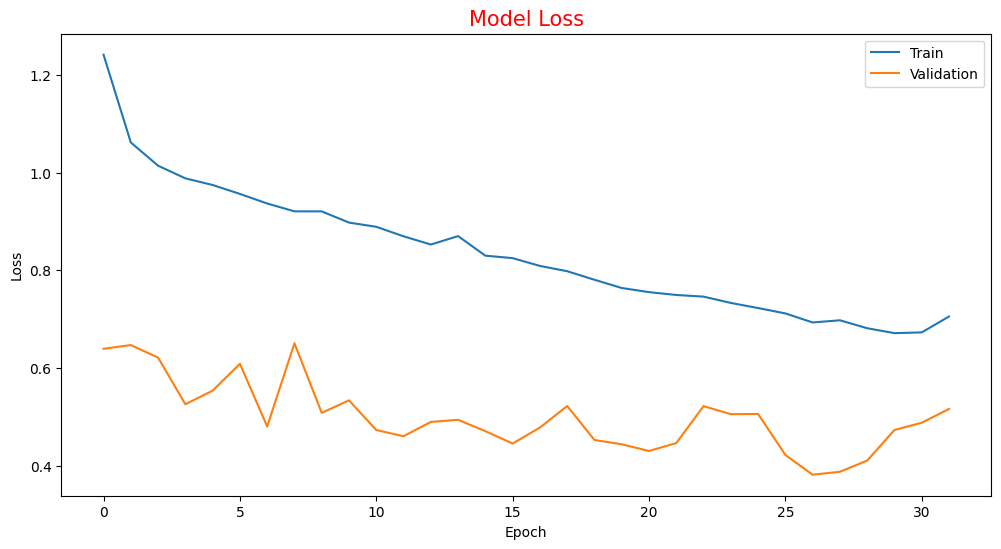

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Model Loss',color='red',fontsize=15)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'],loc='upper right')
plt.show()


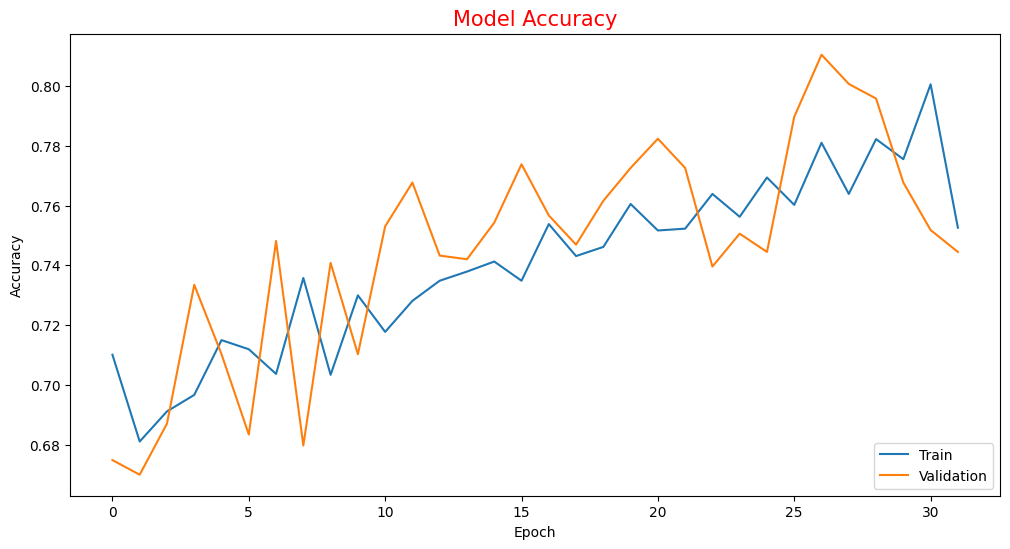

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Model Accuracy',color='red',fontsize=15)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'],loc='lower right')
plt.show()

In [ ]:
loss, accuracy, precision, recall= model.evaluate(x_test_transform, y_test)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")




32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.1511 - Recall: 0.5484 - accuracy: 0.7857 - loss: 0.3996
Loss: 0.399564266204834
Accuracy: 0.7857142686843872
Precision: 0.15111111104488373
Recall: 0.5483871102333069


# Imbalanced Dataset
this is imbalanced dataset so the target column is Stroke the value of No stroke means 0 is 4861 and the column is yes Stroke is means 1 is just 249 that why my '90 %' training  data train with 0 . its probability of wrorng prediction is high.   